## Import des dépendances nécessaires

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

## Import du dataset

In [14]:
print("Import dataset...")
df= pd.read_csv("../data/train_split.csv")
print("Import reussi !")
print()
print("Infos dataset")
print("-"*30)
print()
print(df.info(verbose=True, show_counts=True))

Import dataset...
Import reussi !

Infos dataset
------------------------------

<class 'pandas.DataFrame'>
RangeIndex: 1019826 entries, 0 to 1019825
Data columns (total 11 columns):
 #   Column                      Non-Null Count    Dtype  
---  ------                      --------------    -----  
 0   id                          1019826 non-null  str    
 1   period                      1019826 non-null  int64  
 2   operation                   1019826 non-null  str    
 3   amount                      1019826 non-null  float64
 4   origin_account              1019826 non-null  str    
 5   origin_balance_before       1019826 non-null  float64
 6   origin_balance_after        1019826 non-null  float64
 7   destination_account         1019826 non-null  str    
 8   destination_balance_before  1019826 non-null  float64
 9   destination_balance_after   1019826 non-null  float64
 10  fraud_flag                  1019826 non-null  int64  
dtypes: float64(5), int64(2), str(4)
memory usage:

## Analyse exploratoire et statistique

Nous savons déjà de par la première phase du projet (notebooks/1.0-exploration.ipynb) que :
* La donnée ne contient ni doublons, ni valeurs manquantes.
* Les variables numériques (numériques continues) sont : `amount`, `origin_balance_before`, `origin_balance_after`, `destination_balance_before`, `destination_balance_after`.
* Les variables catégorielles sont : `period`, `operation`, `origin_account`, `destination_account`, `fraud_flag`.
* La variable cible que nous cherchons à prédire est `fraud_flag` : 0 pour une transaction légitime et 1 pour une transaction frauduleuse.

In [15]:
print("10 premieres lignes")
df.head(10)

10 premieres lignes


,id,period,operation,amount,origin_account,origin_balance_before,origin_balance_after,destination_account,destination_balance_before,destination_balance_after,fraud_flag
0,dtf_0000001_ffa5beb5,0,op_05,636.75,acc_o_307358626ad66fed,87.00,-549.75,acc_d_7fac3b16af7d127b,630.88,1267.62,0
1,dtf_0000002_61992e82,0,op_05,636.12,acc_o_aeb690c57bf5d1de,76.93,76.93,acc_d_1d6120e8b117aa14,731.70,731.70,0
2,dtf_0000003_9a123b6d,0,op_05,681.00,acc_o_655c41913944d2b7,15943.74,15262.75,acc_d_ec2c21517a0ccb1a,758.83,1439.84,0
3,dtf_0000004_240f3dae,0,op_03,28175.40,acc_o_ba23a2b955a79a8b,-443.88,-28619.28,acc_d_a3dd8504815ec133,770924.84,799100.24,0
4,dtf_0000005_f18939e7,0,op_03,86429.15,acc_o_d05a23079bd066c1,-670.85,-87100.01,acc_d_0d4880267e62d5c4,91.13,86520.29,0
5,dtf_0000006_64d9bfcb,0,op_05,787.04,acc_o_6d8f4254f3f09623,25.81,25.81,acc_d_d2528fd81d284bd6,0.00,0.00,0
6,dtf_0000007_12c897cc,0,op_05,771.06,acc_o_6ad1fd4988e085ad,572637.44,571866.37,acc_d_256141e7a7c7947e,629.98,1401.04,0
7,dtf_0000008_2017ee18,0,op_05,758.83,acc_o_ed558e2b5b5af5f7,115.21,-643.62,acc_d_89927ea80de472e6,0.00,758.83,0
8,dtf_0000009_7388f093,0,op_03,96800.66,acc_o_9cc0fd44ac3f05d3,-658.41,-97459.06,acc_d_a0682983bf40c207,70.76,96871.41,1
9,dtf_0000010_c0647632,0,op_05,649.32,acc_o_d185654afcfec4e4,93.32,93.32,acc_d_4a34c3d6fd957589,706.31,706.31,0


In [16]:
print("10 dernieres lignes")
df.tail(10)

10 dernieres lignes


,id,period,operation,amount,origin_account,origin_balance_before,origin_balance_after,destination_account,destination_balance_before,destination_balance_after,fraud_flag
1019816,dtf_1019817_9aa1c5a6,74,op_05,724.34,acc_o_135c4bd2386e29d7,3820839.27,3820114.93,acc_d_33d9676a4b3150c0,123137.93,123862.26,0
1019817,dtf_1019818_675f8912,74,op_05,669.93,acc_o_71c1c9aeaa5b08a7,2967267.71,2966597.78,acc_d_8fecca8d3c1fd44b,145556.36,146226.30,0
1019818,dtf_1019819_ad39c6df,74,op_05,678.41,acc_o_774757efa5f80ece,2705912.24,2705233.83,acc_d_e101a820e091a9b7,300099.75,300778.16,0
1019819,dtf_1019820_31c323a2,74,op_03,87191.77,acc_o_8da9c107299e5fbc,2506066.37,2418874.62,acc_d_9f46116481dbd908,70164.91,157356.68,1
1019820,dtf_1019821_70e1d550,74,op_03,24363.91,acc_o_0d5fddd4cccb103d,3976706.09,3952342.19,acc_d_e85644c7c946564d,45249.98,69613.88,1
1019821,dtf_1019822_91a59497,74,op_03,19858.60,acc_o_887ccd116994c9c3,3576589.94,3556731.34,acc_d_e5d9ea2aff4eb782,68203.14,88061.73,1
1019822,dtf_1019823_3c8fd222,74,op_03,23115.44,acc_o_4eb79dd7cb80fd36,3935048.02,3911932.56,acc_d_d7d809915ae9bf2b,0.00,23115.44,0
1019823,dtf_1019824_6c03fdf4,74,op_03,27823.95,acc_o_891c3a3264bbe5d9,3931895.36,3904071.42,acc_d_39813221732ef521,107448.42,135272.37,1
1019824,dtf_1019825_1130e6c4,74,op_05,633.08,acc_o_d131bf48f5f84590,2567496.04,2566862.95,acc_d_0afe38c5a5e6761f,302925.88,303558.97,0
1019825,dtf_1019826_1253886d,74,op_03,32031.15,acc_o_398d6e6000e9926f,4126519.78,4094488.64,acc_d_d8fae01eb75a44f5,23493.77,55524.92,1


In [17]:
print("15 lignes aleatoires")
df.sample(15)

15 lignes aleatoires


,id,period,operation,amount,origin_account,origin_balance_before,origin_balance_after,destination_account,destination_balance_before,destination_balance_after,fraud_flag
397558,dtf_0397559_6d27a732,21,op_05,632.67,acc_o_077d58ea2d6488b5,5109113.26,5108480.59,acc_d_f1142e14c42d0d73,27564.87,28197.53,0
100649,dtf_0100650_4cfadd82,9,op_04,70172.94,acc_o_3f5f281aae7dcffa,1900644.93,1970817.88,acc_d_15c63a9f248e0357,5412.60,5412.60,0
877657,dtf_0877658_fde3e8cc,57,op_05,746.04,acc_o_bb31cac33f4d11de,5448227.85,5447481.81,acc_d_13c35e81262cafb2,129865.43,130611.47,0
336065,dtf_0336066_7b0b836a,19,op_04,207168.80,acc_o_cdde785ed2c8be8b,2034886.37,2242055.17,acc_d_d45191e802dc185c,63266.29,63266.29,0
898950,dtf_0898951_ebb2541e,59,op_03,28517.62,acc_o_d43f282d5ff4da97,3360592.17,3332074.56,acc_d_2ebf12719a95c1cd,281277.40,309795.01,1
357474,dtf_0357475_4c08bcc1,20,op_02,149941.60,acc_o_aeebec8d602fe7c2,3634221.01,3484279.41,acc_d_5bfaccfd558a564b,34096.20,34096.20,0
461164,dtf_0461165_265c172a,26,op_05,685.70,acc_o_bafb2e41726179c3,5638086.96,5637401.27,acc_d_df0f712828587a11,65609.07,66294.77,0
637891,dtf_0637892_4ef43511,40,op_02,38584.73,acc_o_037d68cf98cb3c20,4065170.70,4026585.97,acc_d_23ae369424bbaed4,156813.25,156813.25,0
317379,dtf_0317380_dd1e3528,18,op_05,12397.59,acc_o_0e7310074990a635,3903650.72,3891253.12,acc_d_ffdc60e4dc73b4f1,7761.06,20158.65,0
584230,dtf_0584231_e09f414b,37,op_02,204728.25,acc_o_cc48d52c14ccc676,2255237.88,2050509.62,acc_d_dfab3e1b30c0e87a,134647.58,134647.58,0


### Analyse de la cible 

In [18]:
TARGET= 'fraud_flag'
print(f"Target identifié : {TARGET}")

print()

print("-"*30)
print(f"Repartiton {TARGET}")
print("-"*30)
print(df[TARGET].value_counts())
print()
print(f"Pourcentages respectifs : legit -> {(len(df[df[TARGET]==0])*100 / len(df)):.2f}% | fraudulent -> {(len(df[df[TARGET]==1])*100 / len(df)):.2f}%")

Target identifié : fraud_flag

------------------------------
Repartiton fraud_flag
------------------------------
fraud_flag
0    927947
1     91879
Name: count, dtype: int64

Pourcentages respectifs : legit -> 90.99% | fraudulent -> 9.01%


### Analyse des variables numériques

-----------------------------------
ANALYSE DES VARIABLES NUMÉRIQUES
-----------------------------------

Statistiques descriptives


,amount,origin_balance_before,origin_balance_after,destination_balance_before,destination_balance_after
count,1.019826e+06,1.019826e+06,1.019826e+06,1.019826e+06,1.019826e+06
mean,7.388627e+04,2.903253e+06,2.922370e+06,1.031370e+05,1.198616e+05
std,1.129839e+05,1.672682e+06,1.653449e+06,3.599977e+05,4.089614e+05
min,3.700000e-01,-2.358381e+05,-2.358381e+05,-2.339176e+05,-1.600515e+05
25%,7.401200e+02,1.630930e+06,1.691268e+06,6.441720e+03,2.017408e+04
50%,2.266470e+04,3.201577e+06,3.211368e+06,4.540154e+04,5.617686e+04
75%,1.140785e+05,4.159734e+06,4.158769e+06,1.078649e+05,1.165778e+05
max,2.526958e+06,1.443904e+07,1.443904e+07,1.401552e+07,1.422857e+07



Distribution des variables -- Histogrammes


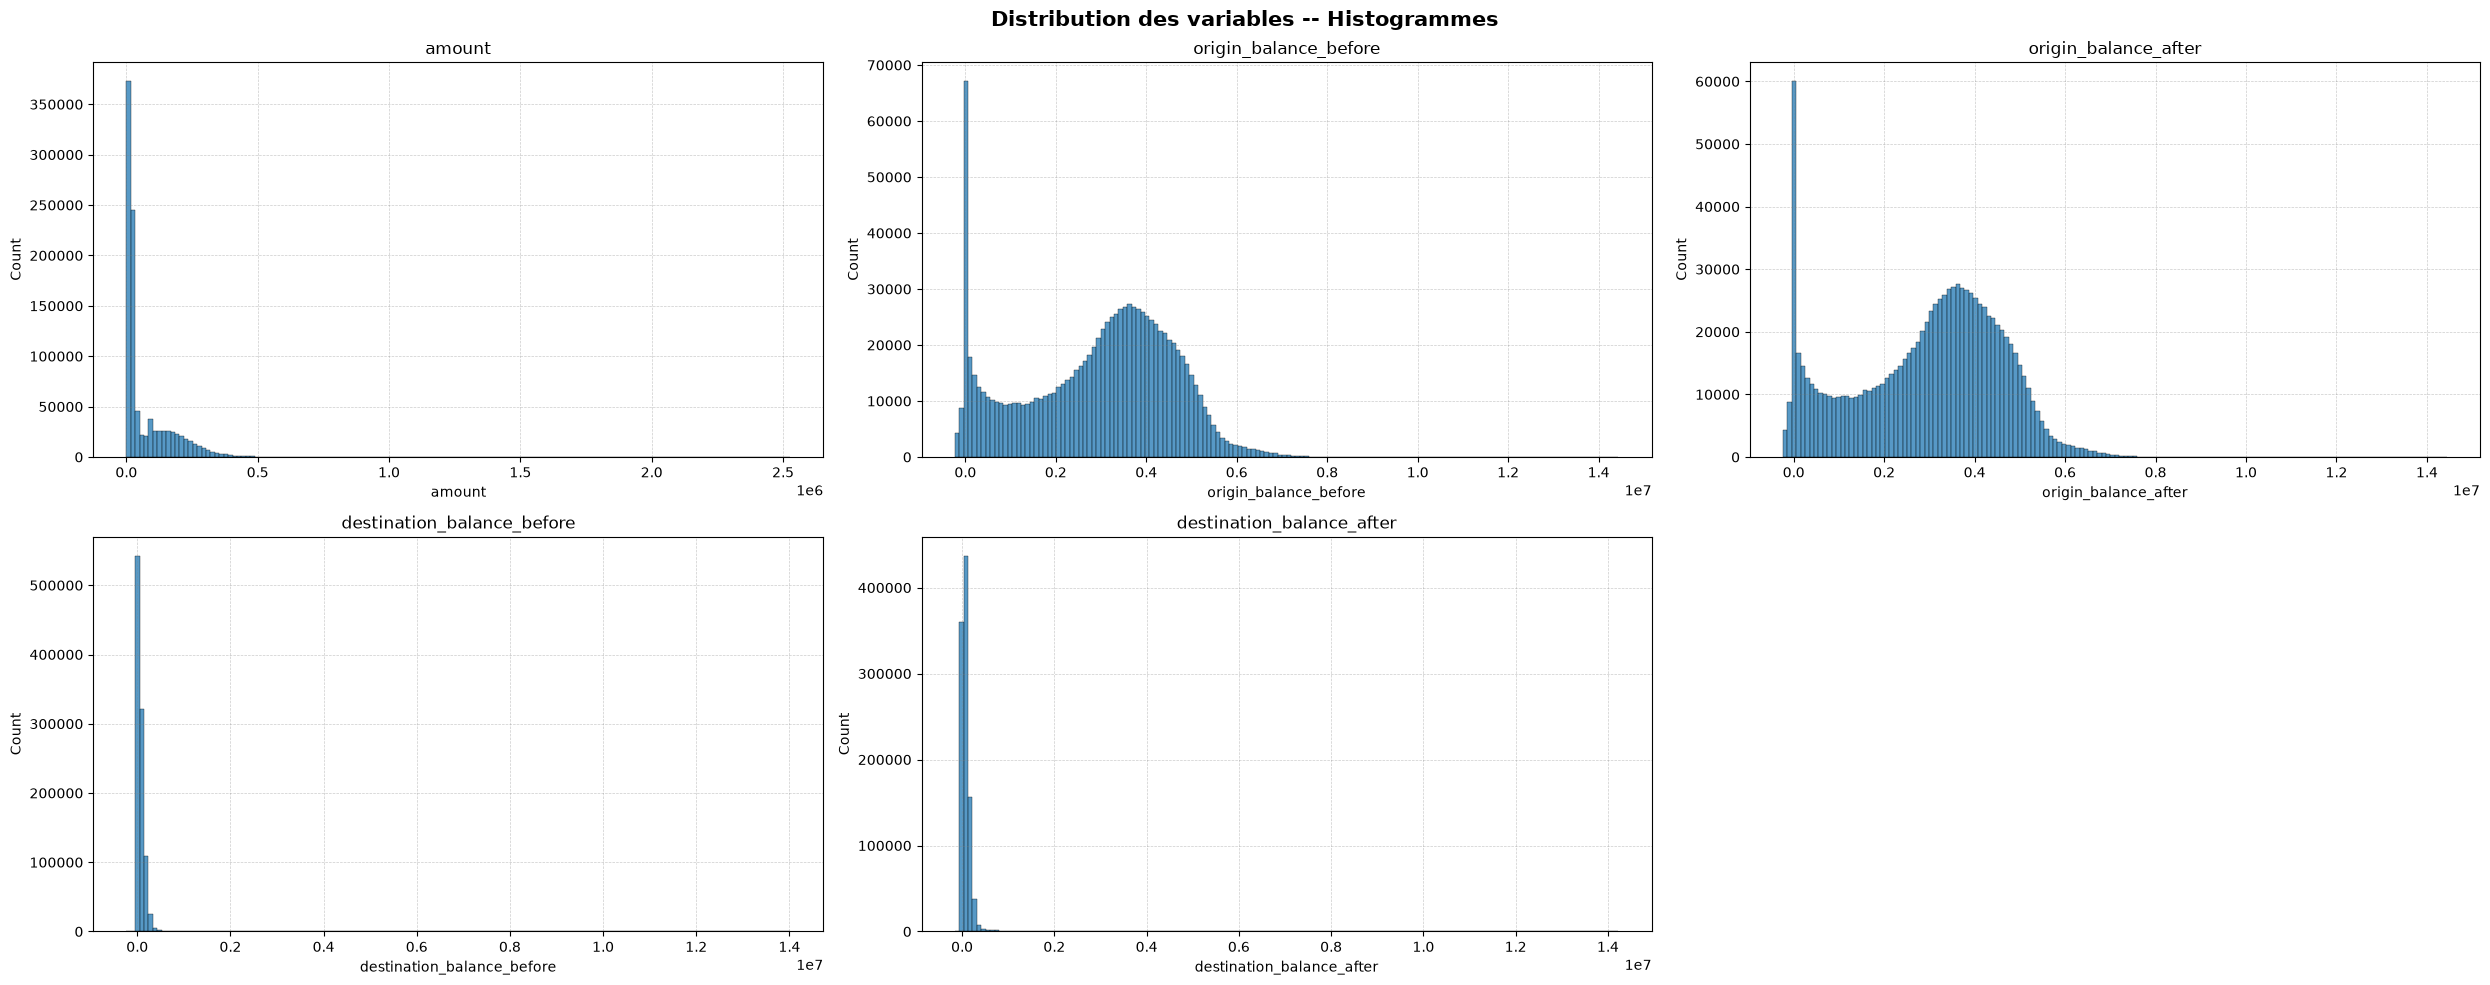


Distribution des variables -- Boxplots


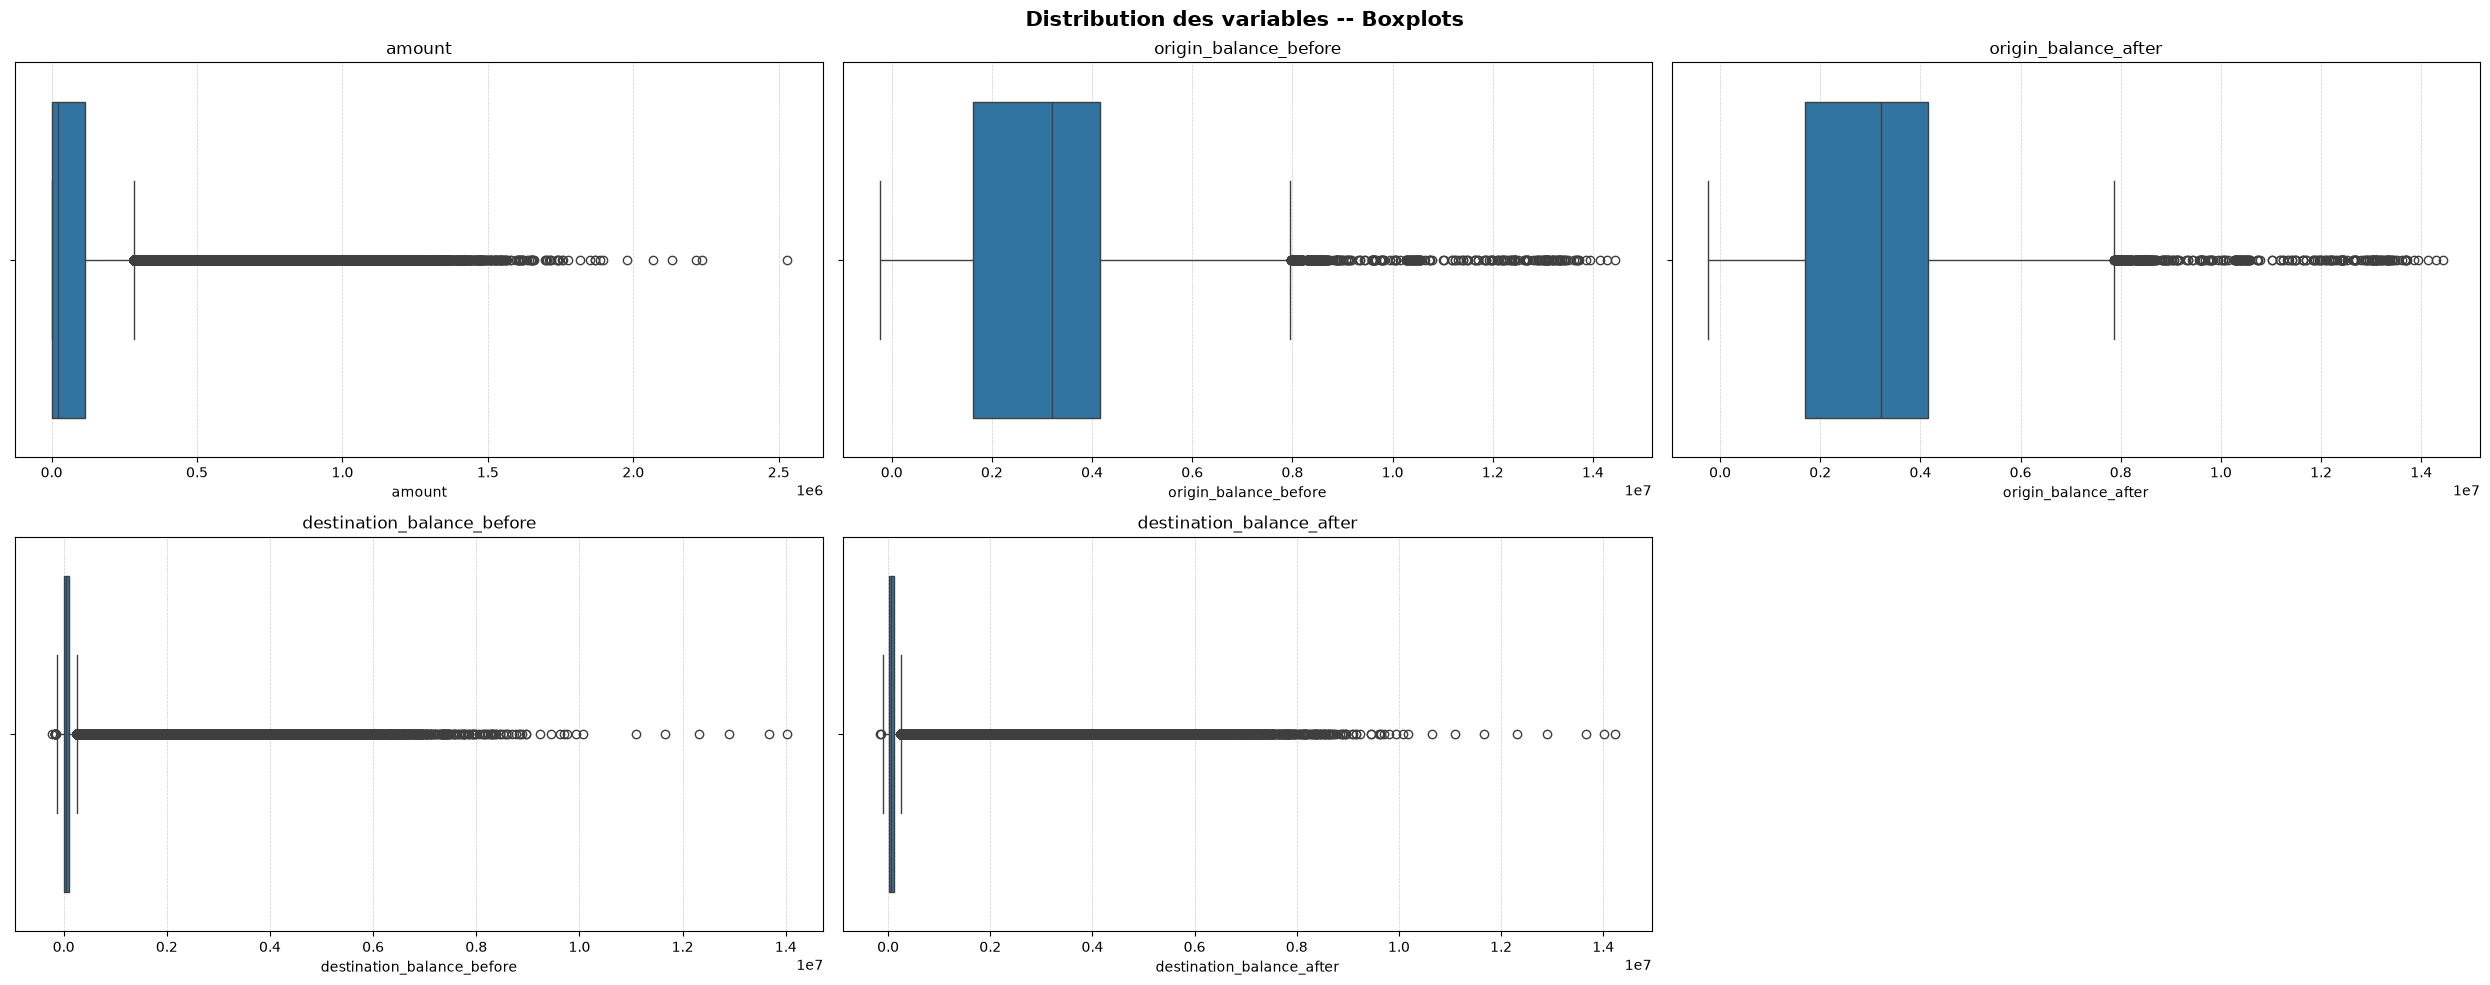

In [19]:
NUM_COLS= ['amount', 'origin_balance_before', 'origin_balance_after', 'destination_balance_before', 'destination_balance_after']

print("-"*35)
print("ANALYSE DES VARIABLES NUMÉRIQUES")
print("-"*35)

print()

print("="*30)
print("Statistiques descriptives")
print("="*30)
display(df[NUM_COLS].describe())

print()

print("="*60)
print("Distribution des variables -- Histogrammes")
print("="*60)

fig1, ax1= plt.subplots(2, 3, figsize=(25, 10))
axs1= ax1.flatten()
fig1.suptitle("Distribution des variables -- Histogrammes", fontsize=15, fontweight='bold')
for i, col in enumerate(NUM_COLS):
    sns.histplot(data=df[col], bins=150, ax=axs1[i])
    axs1[i].set_title(col)
    axs1[i].grid(True, color='gray', alpha=0.4, linewidth=0.5, linestyle='--')
axs1[-1].set_visible(False)
plt.tight_layout()
plt.show()

print()

print("="*60)
print("Distribution des variables -- Boxplots")
print("="*60)

fig2, ax2= plt.subplots(2, 3, figsize=(25, 10))
axs2= ax2.flatten()
fig2.suptitle("Distribution des variables -- Boxplots", fontsize=15, fontweight='bold')
for i, col in enumerate(NUM_COLS):
    sns.boxplot(data=df[col], orient='h', ax=axs2[i])
    axs2[i].set_title(col)
    axs2[i].grid(True, color='gray', alpha=0.4, linewidth=0.5, linestyle='--', axis='x')
axs2[-1].set_visible(False)
plt.tight_layout()
plt.show()

* Toutes les variables présentent une forte proportion d'outliers (valeurs extrèmes) dans leur répartition.
* `amount`, `destination_balance_before`, et `destination_balance_after` sont fortement asymétriques. La plupart des valeurs de ces variables sont concentrées à gauche.
* On remarque des valeurs négatives dans les variables de solde avant et après transaction. 

### Analyse des variables catégorielles

In [20]:
CAT_COLS=['period', 'operation', 'origin_account', 'destination_account']

for col in CAT_COLS:
    msg= f"Nombre de modalites de la variable {col} : {df[col].nunique()}"
    print(msg)

Nombre de modalites de la variable period : 75
Nombre de modalites de la variable operation : 5
Nombre de modalites de la variable origin_account : 13424
Nombre de modalites de la variable destination_account : 15631


### Petit récap des informations acquises sur les variables catégorielles en phase 1

Les résultats et remarques obtenus en phase 1 après analyse de ces variables sont les suivants :
* La variable `period` est quantitative discrète (de 0 à 74).
* La variable `operation` est qualitative nominale et ses cinq modalités sont : `op_01`, `op_02`, `op_03`, `op_04`, `op_05`.
* Les variables `origin_account` et `destination_account` sont qualitatives nominales.

---
### Analyse bivariée

#### Variables numériques vs cible

Analyse bivariee variables numériques vs cible -- Boxplots


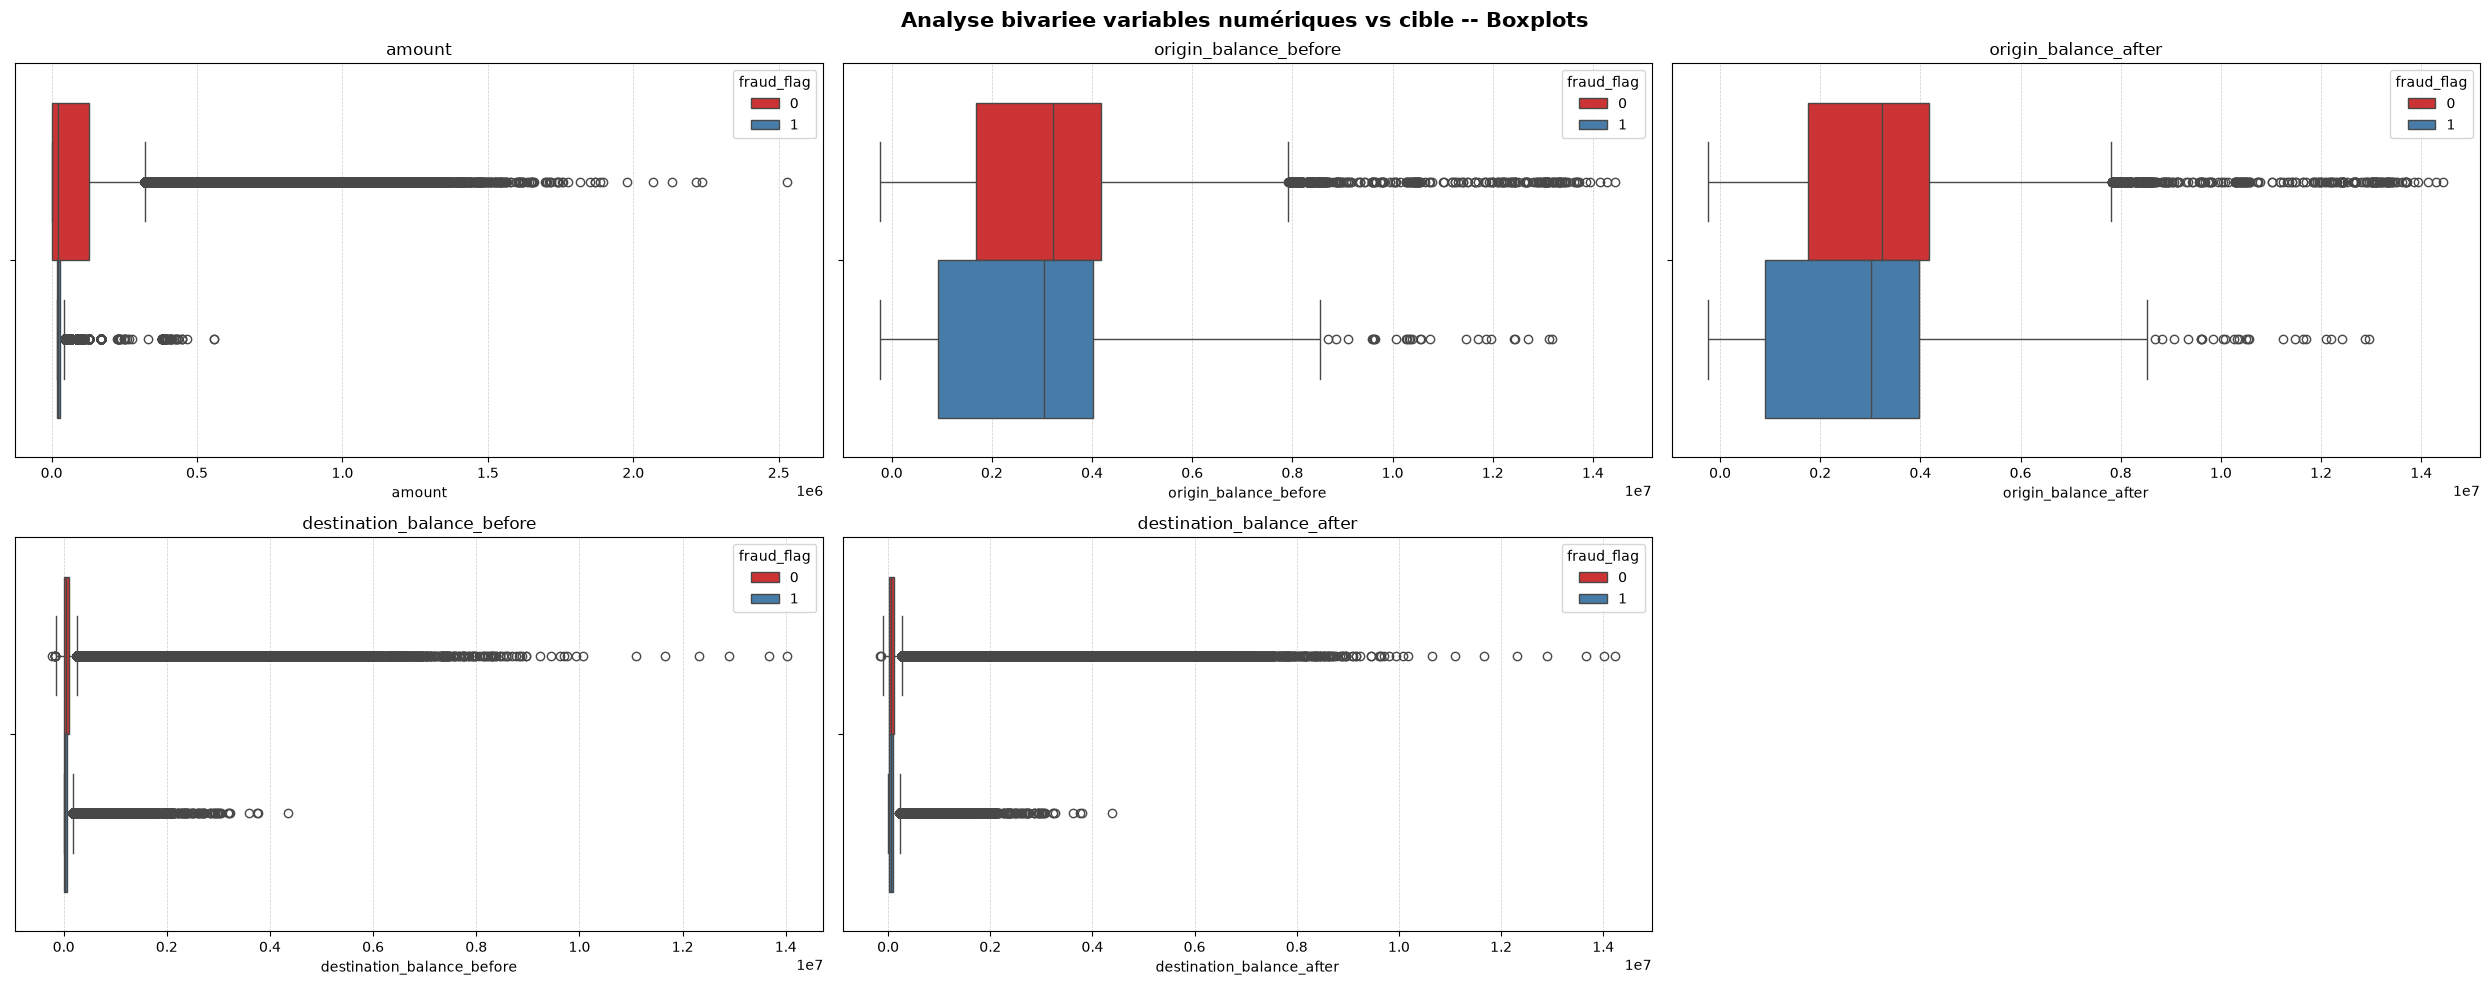

In [30]:
print("="*70)
print("Analyse bivariee variables numériques vs cible -- Boxplots")
print("="*70)

fig1, ax1= plt.subplots(2, 3, figsize=(25, 10))
axs1= ax1.flatten()
fig1.suptitle("Analyse bivariee variables numériques vs cible -- Boxplots", fontsize=15, fontweight='bold')
for i, col in enumerate(NUM_COLS):
    sns.boxplot(data=df, x=col, orient='h', hue=TARGET, ax=axs1[i], palette='Set1')
    axs1[i].set_title(col)
    axs1[i].grid(True, color='gray', alpha=0.4, linewidth=0.5, linestyle='--', axis='x')
axs1[-1].set_visible(False)
plt.tight_layout()
plt.show()

**Interprétation** 
---

* Bien que les médianes des deux classes se superposent presque pour la variable `amount`, on note une différence d'échelle notable en les deux boxplots, signe qu'une correction log serait pertinent pour cette variable.
* Cette remarque est la même pour les variables `destination_balance_before` et `destination_balance_after` mais une correction log est impossible cette fois en raison des valeurs négatives présentes dans leurs valeurs. 